In [ ]:
import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline
import missingno as miss
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')  

from imblearn.over_sampling import SMOTE
import itertools

# 1. EDA

In [ ]:
data = pd.read_csv("creditcard.csv")
df = data.copy()
pd.set_option('display.float_format', lambda x: '%.3f' % x)# Read the input data and keep three decimal places.
df.head() # Read the first 5 rows of the data to quickly check the basic information of the data.

   Time     V1     V2    V3     V4     V5     V6     V7     V8     V9  ...  \
0 0.000 -1.360 -0.073 2.536  1.378 -0.338  0.462  0.240  0.099  0.364  ...   
1 0.000  1.192  0.266 0.166  0.448  0.060 -0.082 -0.079  0.085 -0.255  ...   
2 1.000 -1.358 -1.340 1.773  0.380 -0.503  1.800  0.791  0.248 -1.515  ...   
3 1.000 -0.966 -0.185 1.793 -0.863 -0.010  1.247  0.238  0.377 -1.387  ...   
4 2.000 -1.158  0.878 1.549  0.403 -0.407  0.096  0.593 -0.271  0.818  ...   

     V21    V22    V23    V24    V25    V26    V27    V28  Amount  Class  
0 -0.018  0.278 -0.110  0.067  0.129 -0.189  0.134 -0.021 149.620      0  
1 -0.226 -0.639  0.101 -0.340  0.167  0.126 -0.009  0.015   2.690      0  
2  0.248  0.772  0.909 -0.689 -0.328 -0.139 -0.055 -0.060 378.660      0  
3 -0.108  0.005 -0.190 -1.176  0.647 -0.222  0.063  0.061 123.500      0  
4 -0.009  0.798 -0.137  0.141 -0.206  0.502  0.219  0.215  69.990      0  

[5 rows x 31 columns]


As can be seen from the above, the data is **structured data**, so no feature extraction and transformation are required. However, the data scales of the features **"Time"** and **"Amount"** are different from those of other features, so **feature scaling** needs to be performed on them.

In [19]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

1. This dataset has 280,000 rows and 31 columns.
2. Check the basic data types and missing value status

<Axes: >

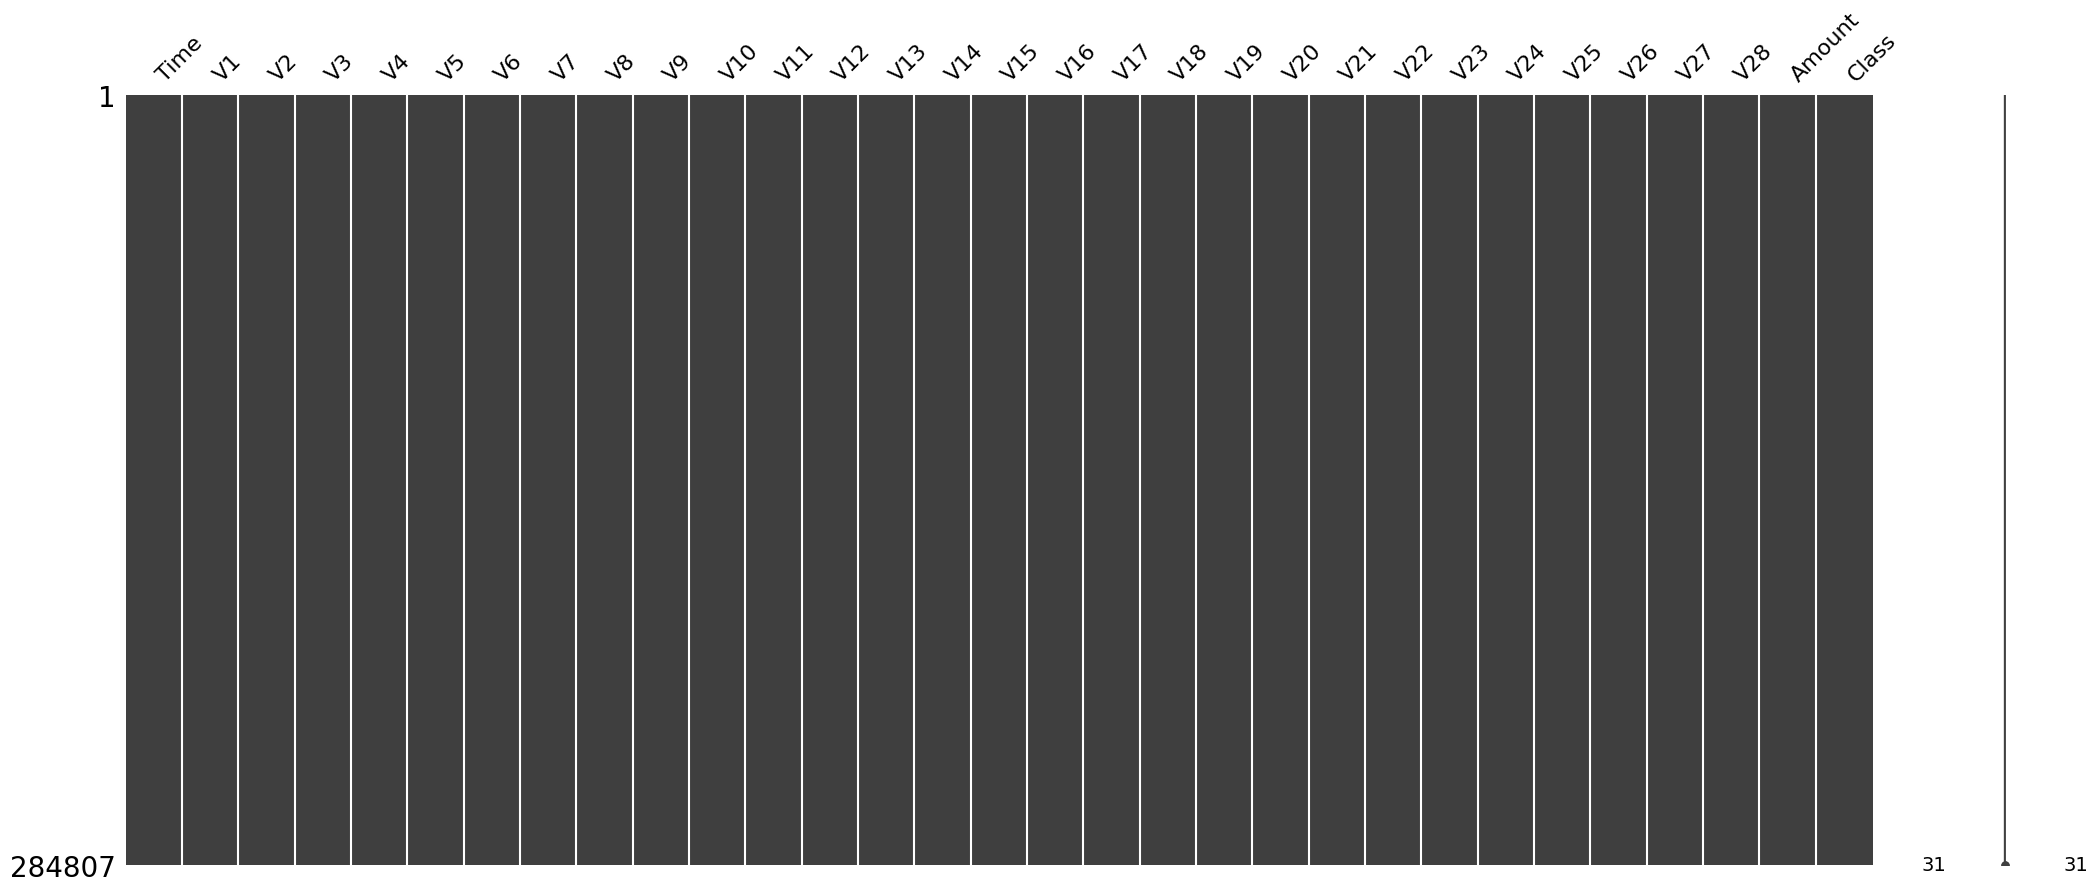

In [ ]:
miss.matrix(df)

The data types are only float64 and int64, with no missing values, which facilitates subsequent processing.

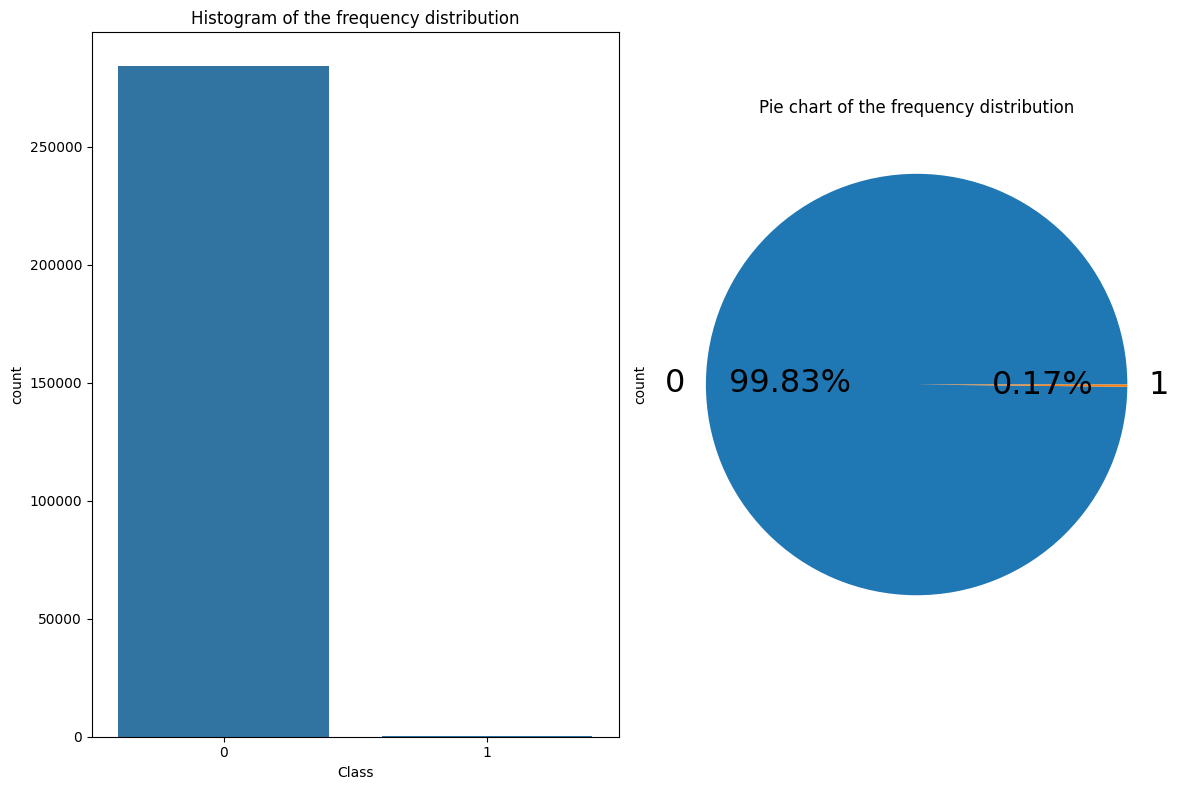

In [28]:

# Create subplots with 1 row, 2 columns for side-by-side visualization
fig,ax = plt.subplots(1,2,figsize=(12,8))

# Create a count plot showing frequency of each class
sns.countplot(x="Class",data=df,ax=ax[0])

# Add title to the bar chart
ax[0].set_title("Histogram of the frequency distribution")

# Create a pie chart showing percentage distribution of each class
df["Class"].value_counts().plot(kind="pie",ax=ax[1],fontsize=23,autopct='%1.2f%%')
ax[1].set_title("Pie chart of the frequency distribution")
plt.tight_layout()
plt.show()

In [18]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

From the above graphs and data, it can be seen that there are 492 cases of fraudulent transactions, accounting for 0.17% of the total samples. This indicates an obvious **data class imbalance problem**, and we will use the **oversampling (data augmentation) method** to address this issue later.

# 2. Feature Engineering

## Feature Transformation

In [62]:
df['Time']=df['Time'].apply(lambda x : divmod(x ,3600)[0])

### Visual analysis of feature distribution

#### Full Feature Distribution Analysis

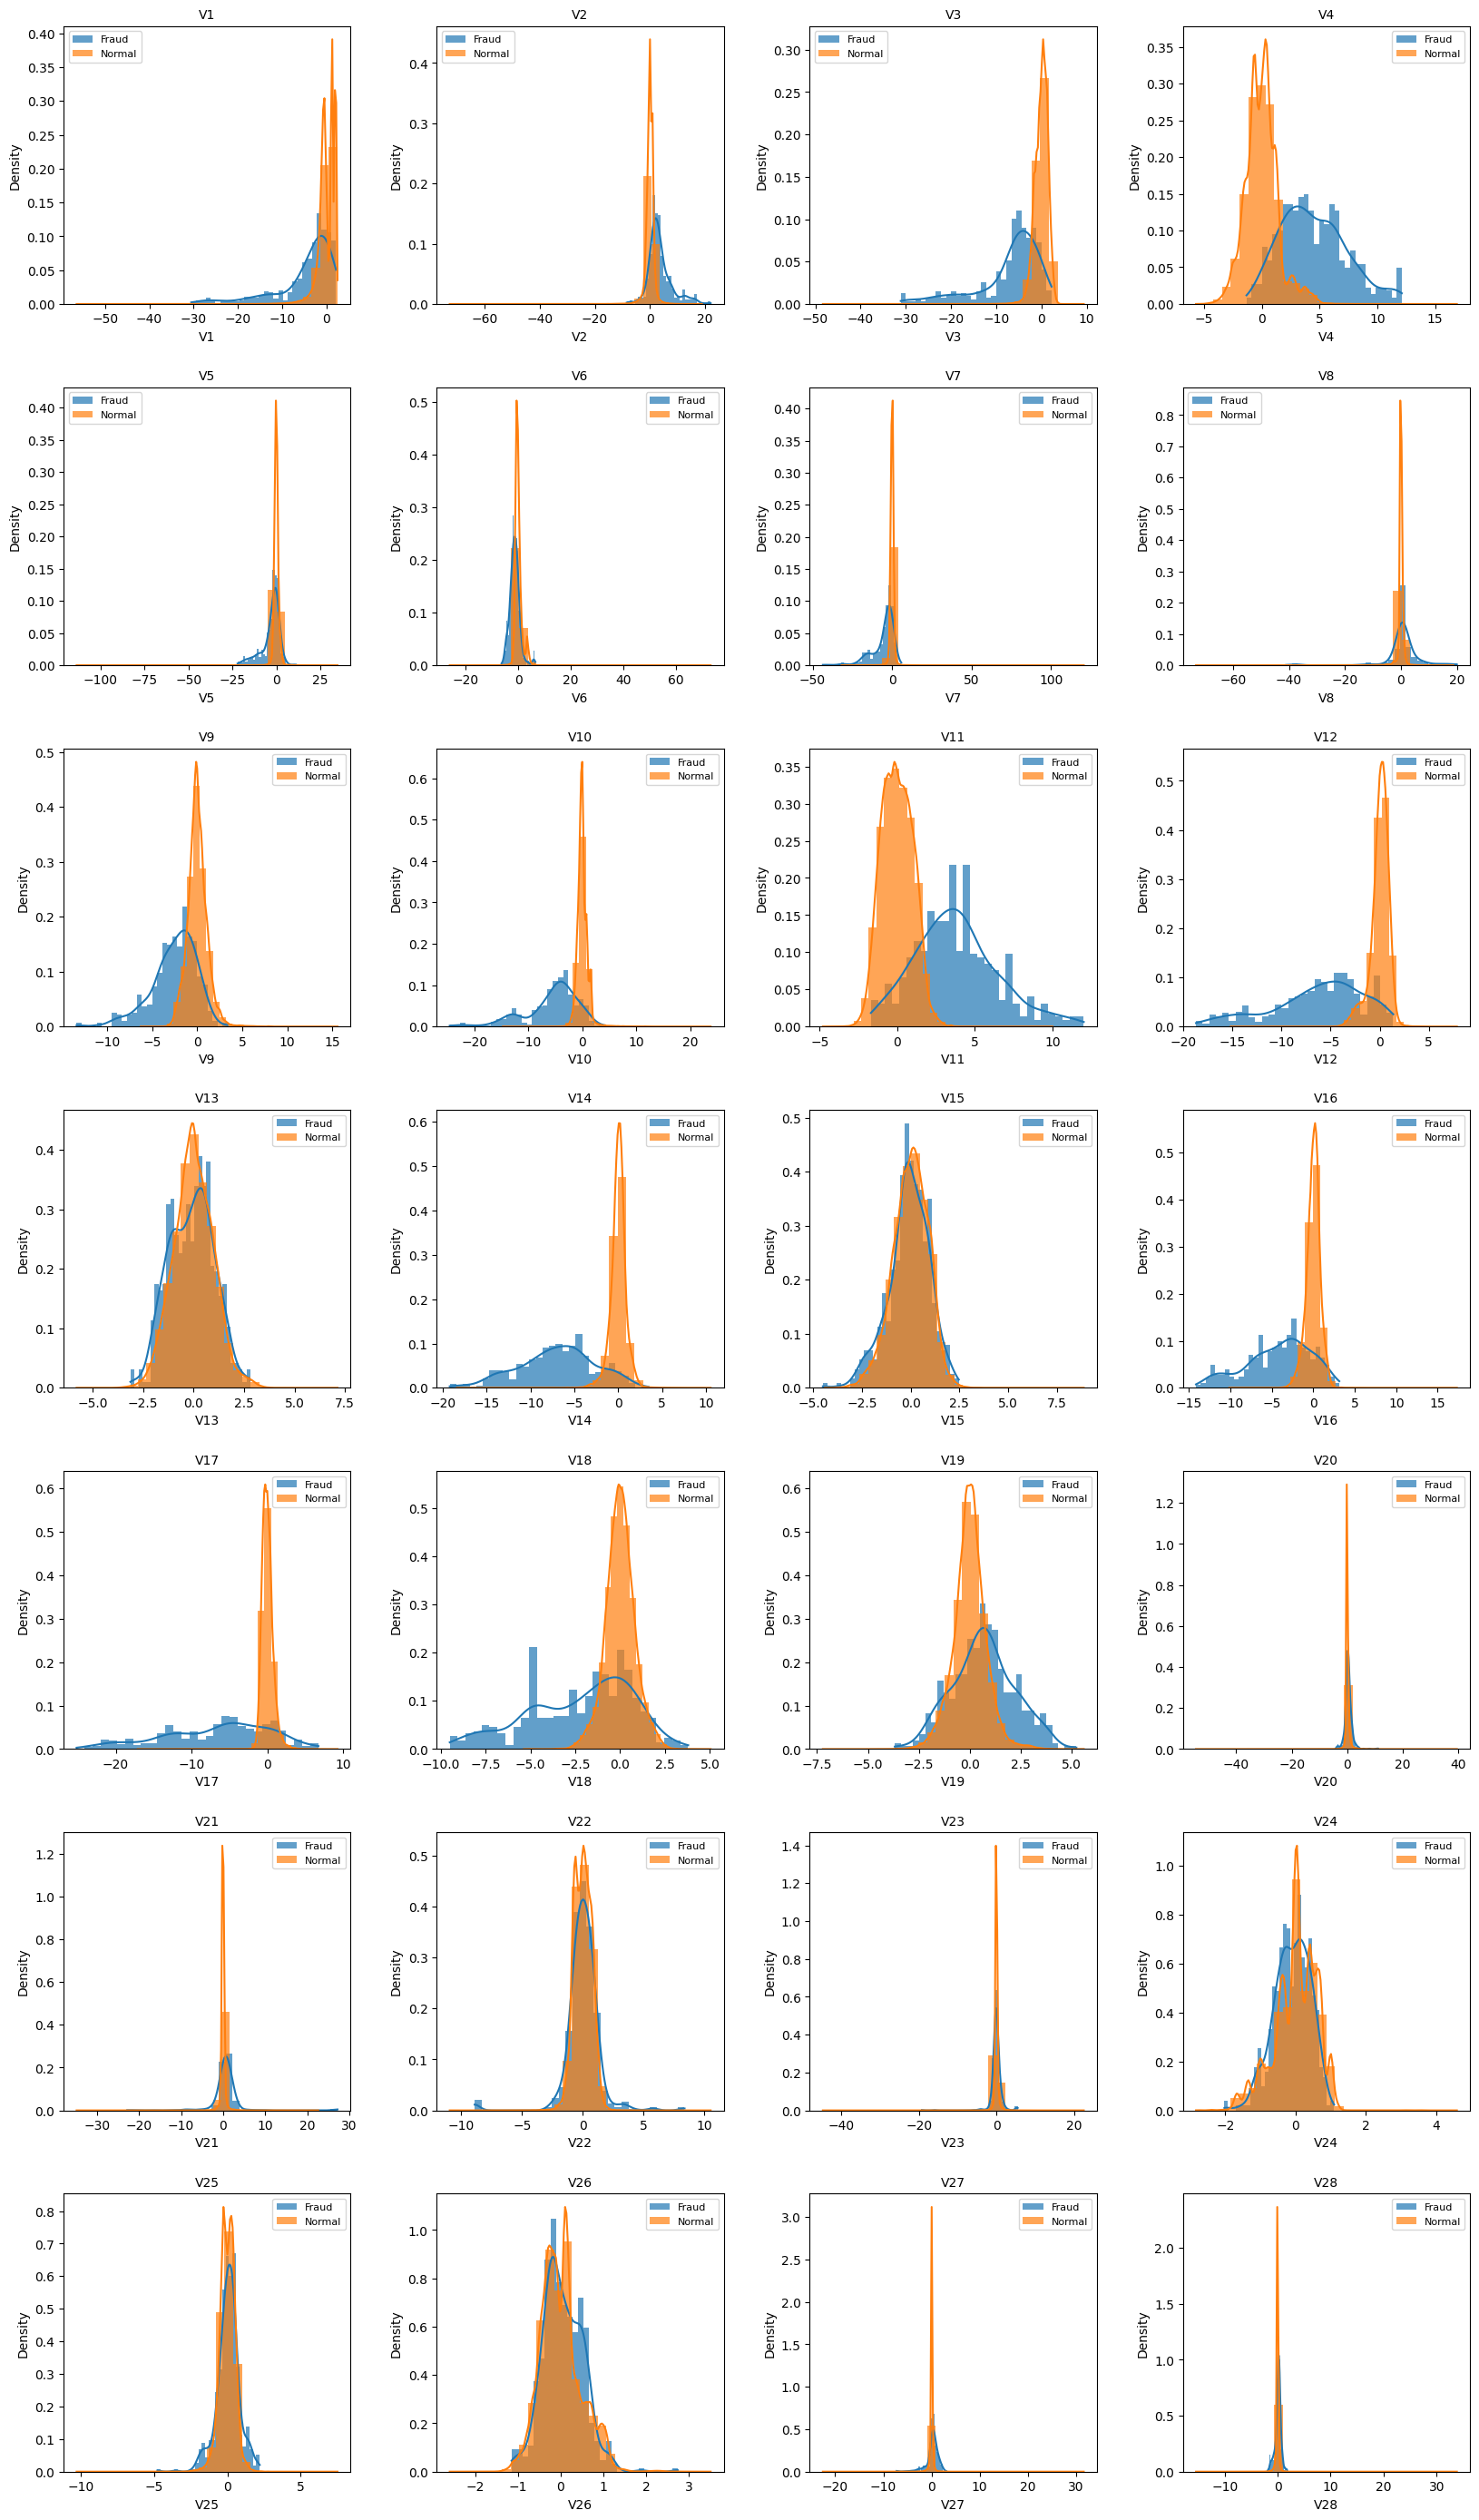

In [63]:
v_feature = df.iloc[:,1:29].columns
plt.figure(figsize=(20, 35))
gs = gridspec.GridSpec(7, 4, hspace=0.3, wspace=0.3)

for i,cn in enumerate(v_feature):
    row = i // 4  # 计算行位置
    col = i % 4   # 计算列位置
    ax = plt.subplot(gs[row, col])
    
    fraud_data = df[df["Class"]==1][cn]
    normal_data = df[df["Class"]==0][cn]
    
    sns.histplot(fraud_data, bins=30, label='Fraud', alpha=0.7, kde=True, 
                stat="density", edgecolor='none')
    sns.histplot(normal_data, bins=30, label='Normal', alpha=0.7, kde=True, 
                stat="density", edgecolor='none')
    
    ax.set_title(f"{cn}", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Correlation-Filtered Feature Analysis

In [ ]:
fraud_corr = abs(df.corr()['Class']).sort_values(ascending=False)
low_corr_features = fraud_corr[fraud_corr < 0.03].index
print(f"Low Correlation feature: {low_corr_features.tolist()}")

Low Correlation feature: ['V20', 'V8', 'V27', 'Time', 'V28', 'V24', 'Amount', 'V13', 'V26', 'V15', 'V25', 'V23', 'V22']


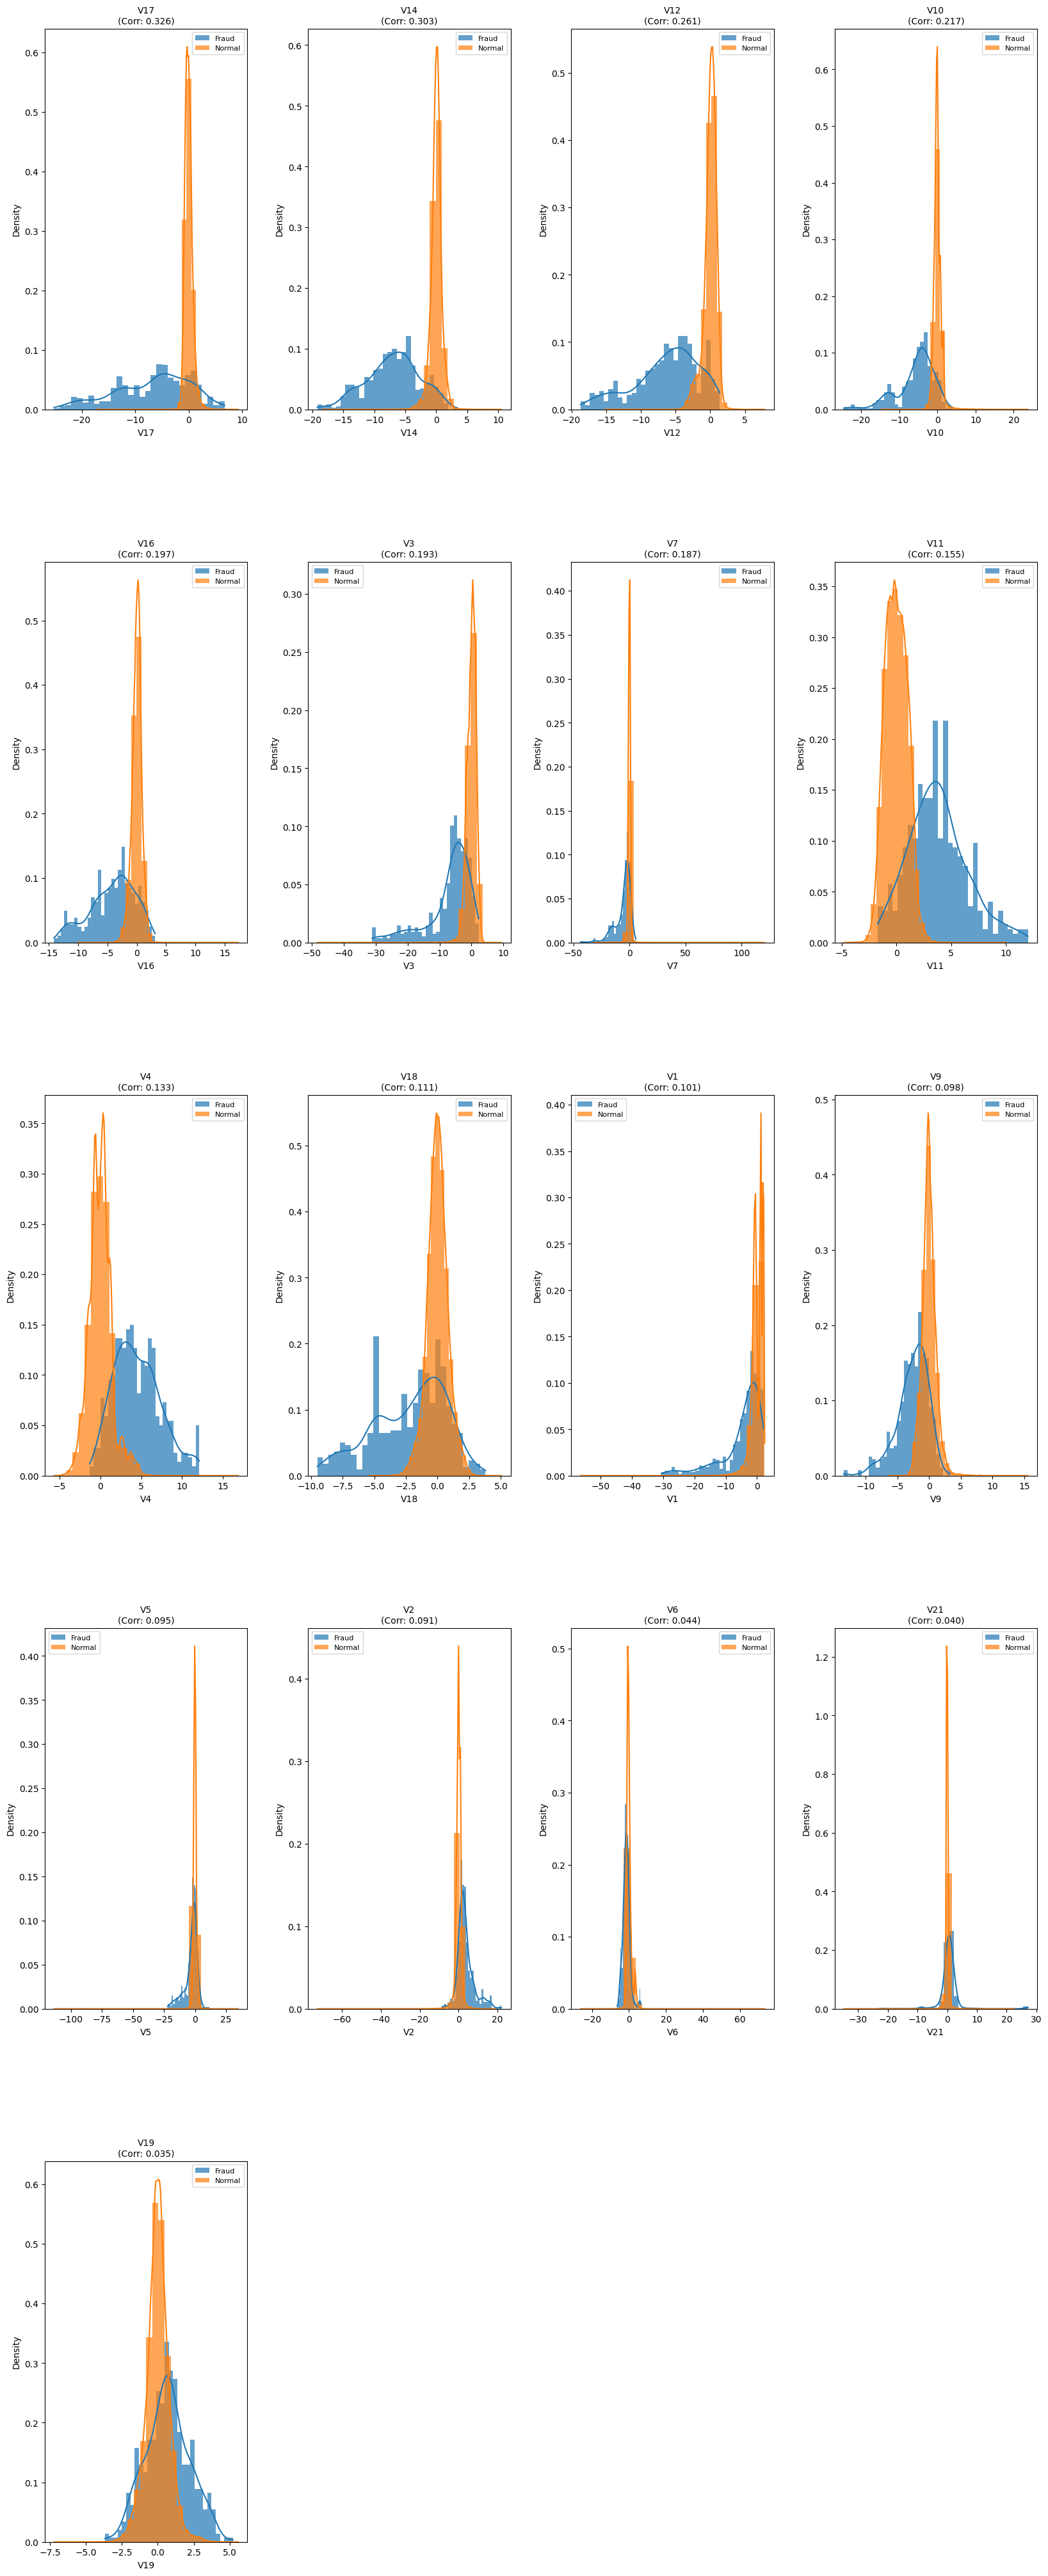

In [ ]:
# high_corr_features = fraud_corr[fraud_corr >= 0.03].drop('Class')
# n_features = len(high_corr_features)
# fig = plt.figure(figsize=(20, n_features*3))
# gs = gridspec.GridSpec(n_features//4 + 1, 4, hspace=0.4, wspace=0.3)

# for i, feature_name in enumerate(high_corr_features.index):
#     row = i // 4
#     col = i % 4
#     ax = plt.subplot(gs[row, col])
    
#     fraud_data = df[df["Class"]==1][feature_name]
#     normal_data = df[df["Class"]==0][feature_name]
    
#     sns.histplot(fraud_data, bins=30, label='Fraud', alpha=0.7, kde=True, 
#                 stat="density", edgecolor='none')
#     sns.histplot(normal_data, bins=30, label='Normal', alpha=0.7, kde=True, 
#                 stat="density", edgecolor='none')
    
#     corr_value = fraud_corr[feature_name]
#     ax.set_title(f"{feature_name}\n(Corr: {corr_value:.3f})", fontsize=10)
#     ax.legend(fontsize=8)

# plt.tight_layout()
# plt.show()

Visualize feature distributions and correlations to identify the most discriminative features for fraud detection, then proceed with feature selection and model training using the high-correlation features.

And then remove low-correlation features (V8、V13、V15、V20、V22、V23、V24、V25、V26、V27 and V28) and focus model development on the remaining high-impact variables.

## Feature Selection

In [71]:
droplist=["V8","V13","V15","V20","V22","V23","V24","V25","V26","V27","V28"]
df_new=df.drop(droplist,axis=1)
df_new.shape

(284807, 20)

In [72]:
df_new.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V9', 'V10', 'V11',
       'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V21', 'Amount', 'Class'],
      dtype='object')

## Feature Scaling

In [73]:
df_new.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V9,V10,V11,V12,V14,V16,V17,V18,V19,V21,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.364,0.091,-0.552,-0.618,-0.311,-0.470,0.208,0.026,0.404,-0.018,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,-0.255,-0.167,1.613,1.065,-0.144,0.464,-0.115,-0.183,-0.146,-0.226,2.690,0
2,0.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,-1.515,0.208,0.625,0.066,-0.166,-2.890,1.110,-0.121,-2.262,0.248,378.660,0
3,0.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,-1.387,-0.055,-0.226,0.178,-0.288,-1.060,-0.684,1.966,-1.233,-0.108,123.500,0
4,0.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,0.818,0.753,-0.823,0.538,-1.120,-0.451,-0.237,-0.038,0.803,-0.009,69.990,0


The value ranges of the Amount variable and the Time variable differ significantly from those of other variables, so feature scaling should be performed on them.

In [75]:
col=["Amount","Time"]
from sklearn.preprocessing import StandardScaler
df_new[col]=StandardScaler().fit_transform(df_new[col])
df_new.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V9,V10,V11,V12,V14,V16,V17,V18,V19,V21,Amount,Class
0,-1.960,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.364,0.091,-0.552,-0.618,-0.311,-0.470,0.208,0.026,0.404,-0.018,0.245,0
1,-1.960,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,-0.255,-0.167,1.613,1.065,-0.144,0.464,-0.115,-0.183,-0.146,-0.226,-0.342,0
2,-1.960,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,-1.515,0.208,0.625,0.066,-0.166,-2.890,1.110,-0.121,-2.262,0.248,1.161,0
3,-1.960,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,-1.387,-0.055,-0.226,0.178,-0.288,-1.060,-0.684,1.966,-1.233,-0.108,0.141,0
4,-1.960,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,0.818,0.753,-0.823,0.538,-1.120,-0.451,-0.237,-0.038,0.803,-0.009,-0.073,0


(-1.0, 19.0)

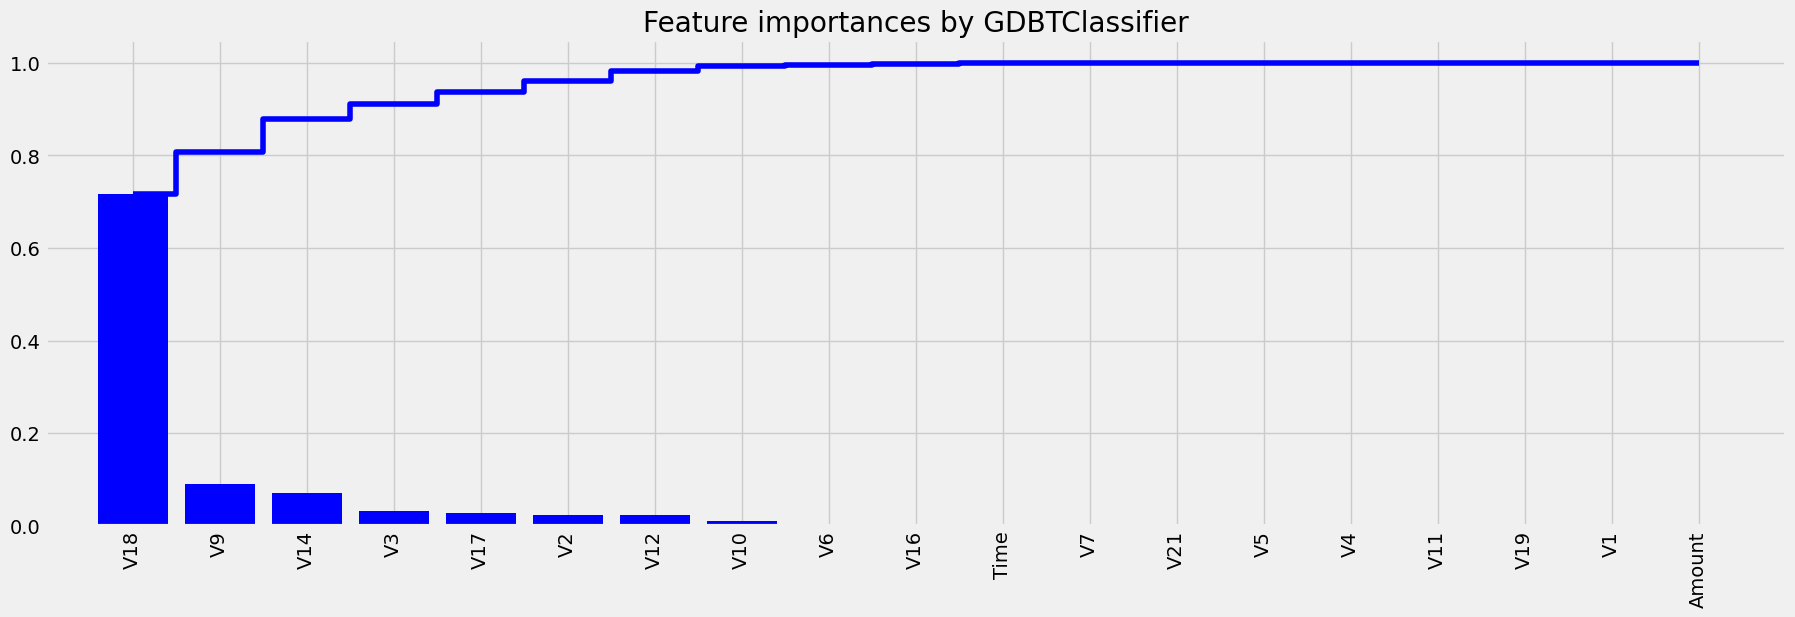

In [ ]:
x_val=df_new.iloc[:,:-1] # except last column 
y_val=df_new.iloc[:,-1] # only contains last column 

from sklearn.ensemble import GradientBoostingClassifier as GDBT
gb_clf=GDBT()
gb_clf.fit(x_val,y_val) # Train modle 

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12,6)

gb_importance=gb_clf.feature_importances_
gb_feature_name=df_new.columns[:-1]
gb_indices=np.argsort(gb_importance)[::-1]

fig = plt.figure(figsize=(20,6))
plt.title("Feature importances by GDBTClassifier")
plt.bar(range(len(gb_importance)),gb_importance[gb_indices],color="blue",align="center")
plt.step(range(len(gb_importance)),np.cumsum(gb_importance[gb_indices]),color="blue",where="mid",label="cumulative")
plt.xticks(range(len(gb_importance)),gb_feature_name[gb_indices],rotation='vertical',fontsize=14)
plt.xlim([-1, len(gb_indices)])

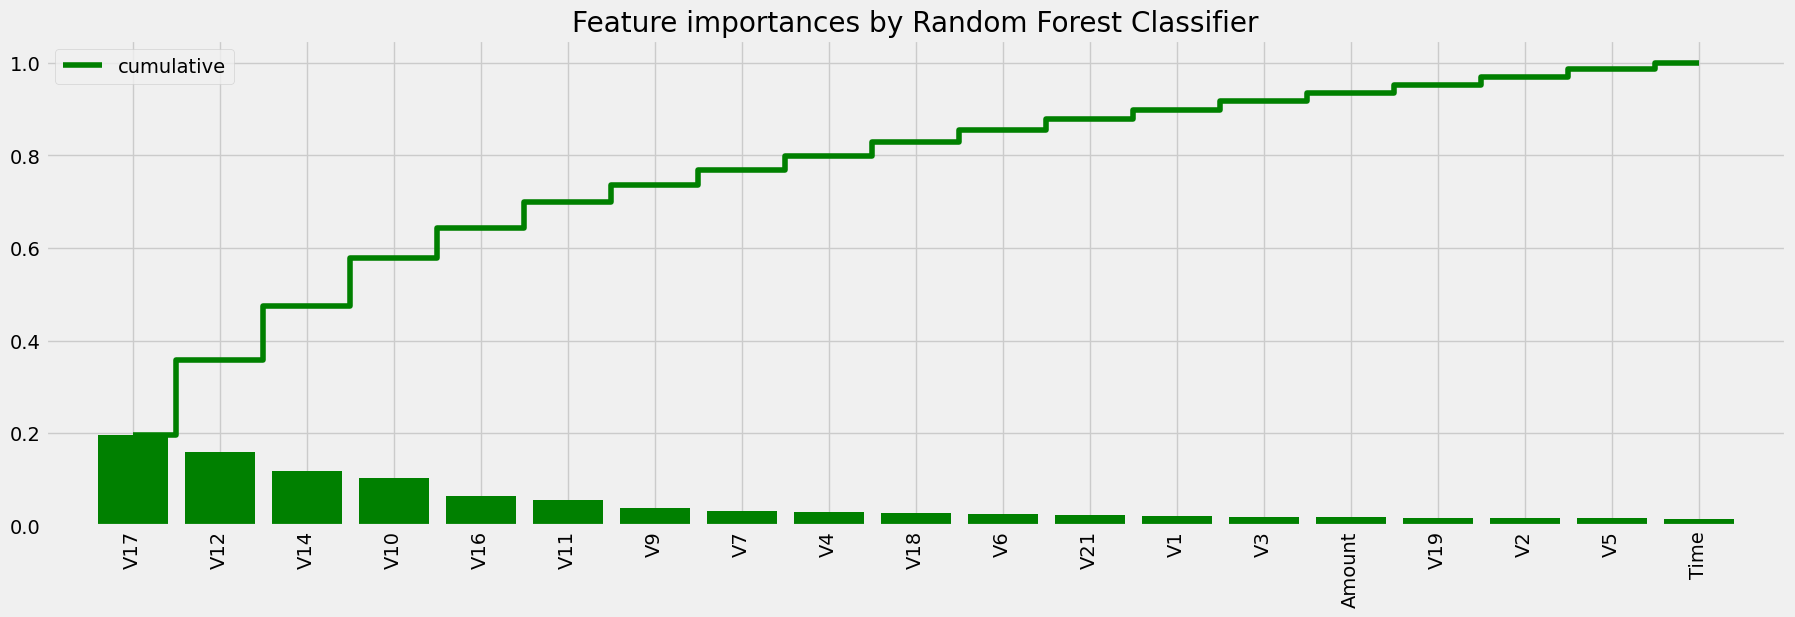

In [82]:
from sklearn.ensemble import RandomForestClassifier as RF
rf_clf = RF(n_estimators=100, random_state=42) 
rf_clf.fit(x_val, y_val)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12,6)

rf_importance = rf_clf.feature_importances_
rf_feature_name = df_new.columns[:-1]
rf_indices = np.argsort(rf_importance)[::-1]

fig = plt.figure(figsize=(20,6))
plt.title("Feature importances by Random Forest Classifier") 
plt.bar(range(len(rf_importance)), rf_importance[rf_indices], color="green", align="center") 
plt.step(range(len(rf_importance)), np.cumsum(rf_importance[rf_indices]), 
         color="green", where="mid", label="cumulative")
plt.xticks(range(len(rf_importance)), rf_feature_name[rf_indices], 
           rotation='vertical', fontsize=14)
plt.xlim([-1, len(rf_indices)])
plt.legend() 
plt.show()

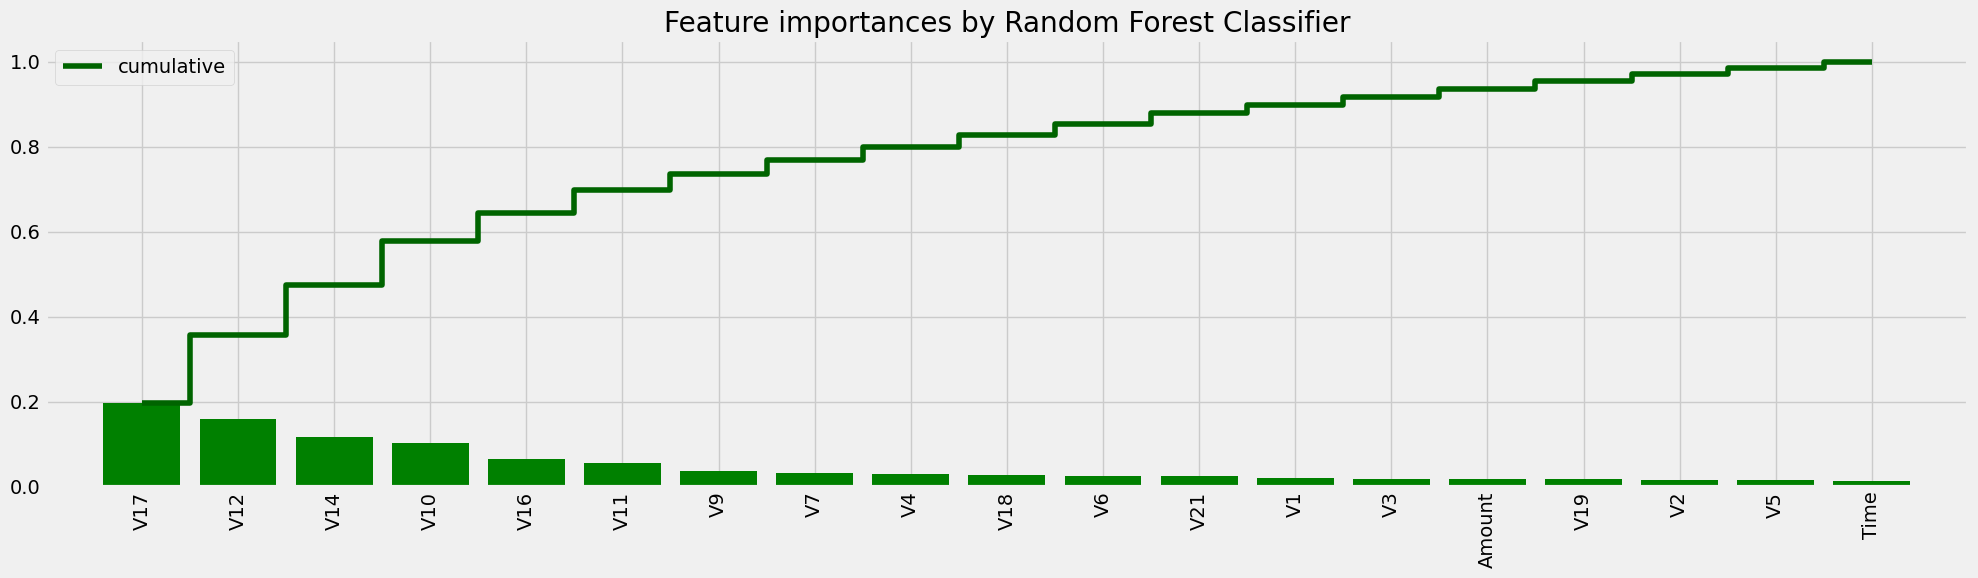

In [83]:
rf_clf = RF(n_estimators=100, random_state=42) 
rf_clf.fit(x_val, y_val)

plt.style.use('fivethirtyeight')

rf_importance = rf_clf.feature_importances_
rf_feature_name = df_new.columns[:-1]
rf_indices = np.argsort(rf_importance)[::-1]

plt.figure(figsize=(20,6))  # 移除fig变量
plt.title("Feature importances by Random Forest Classifier") 
plt.bar(range(len(rf_importance)), rf_importance[rf_indices], color="green", align="center") 
plt.step(range(len(rf_importance)), np.cumsum(rf_importance[rf_indices]), 
         color="darkgreen", where="mid", label="cumulative")  # 改为深绿色以便区分
plt.xticks(range(len(rf_importance)), rf_feature_name[rf_indices], 
           rotation='vertical', fontsize=14)
plt.xlim([-1, len(rf_indices)])
plt.legend()  # 添加图例
plt.tight_layout()  # 优化布局
plt.show() 